In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats


Data Loading & Date Parsing

In [19]:
df = pd.read_csv('C:\\Climate_data\\data\\sudan.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4107, 12)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31
1,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42
2,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06
3,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86
4,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11


In [20]:
print(df.shape)

(4107, 12)


In [21]:
  # Add Country column
df["Country"] = "Sudan"
df.head()
    
   

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country
0,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan
1,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan
2,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan
3,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan
4,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11,Sudan


In [22]:
 # Convert YEAR + DOY → datetime
df["Date"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df.head()
    

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date
0,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02
1,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03
2,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04
3,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05
4,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11,Sudan,2015-01-06


In [23]:
 # Extract Month
df["Month"] = df["Date"].dt.month
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
1,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
2,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
3,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
4,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11,Sudan,2015-01-06,1


Summary Statistics & Missing-Value Report

Information about the Dataset

In [24]:
print("An overview of the dataset: the shape of the dataset")
print(df.info())

An overview of the dataset: the shape of the dataset
<class 'pandas.DataFrame'>
RangeIndex: 4107 entries, 0 to 4106
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   YEAR         4107 non-null   int64         
 1   DOY          4107 non-null   int64         
 2   T2M          4107 non-null   float64       
 3   T2M_MAX      4107 non-null   float64       
 4   T2M_MIN      4107 non-null   float64       
 5   T2M_RANGE    4107 non-null   float64       
 6   PRECTOTCORR  4107 non-null   float64       
 7   RH2M         4107 non-null   float64       
 8   WS2M         4107 non-null   float64       
 9   WS2M_MAX     4107 non-null   float64       
 10  PS           4107 non-null   float64       
 11  QV2M         4107 non-null   float64       
 12  Country      4107 non-null   str           
 13  Date         4107 non-null   datetime64[us]
 14  Month        4107 non-null   int32         
dtypes: datetime64

In [25]:
df.replace(-999, np.nan, inplace=True)

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,2,23.92,34.14,15.81,18.33,0.0,23.83,4.24,5.10,96.67,4.31,Sudan,2015-01-02,1
1,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
2,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
3,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
4,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11,Sudan,2015-01-06,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4102,2026,86,27.89,34.69,21.67,13.02,0.0,14.47,3.66,5.11,96.47,3.52,Sudan,2026-03-27,3
4103,2026,87,28.73,36.61,21.34,15.27,0.0,9.75,3.21,4.40,96.35,2.44,Sudan,2026-03-28,3
4104,2026,88,30.06,38.89,21.15,17.74,0.0,11.63,2.41,3.87,96.10,3.12,Sudan,2026-03-29,3
4105,2026,89,32.50,41.53,23.61,17.92,0.0,14.06,2.81,4.87,95.93,4.18,Sudan,2026-03-30,3


In [26]:
duplicates = df.duplicated().sum()
print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [27]:
# Drop duplicates
df = df.drop_duplicates()

In [28]:
df[df.duplicated()]

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month


Duplicate Rows

I identified 0 duplicate rows in the dataset using df.duplicated().sum().

In [29]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,28.759878,36.774212,21.509817,15.264395,0.644032,31.359067,3.484259,5.157387,96.346226,7.864991,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.500000,13.280000,0.000000,17.405000,2.730000,4.265000,96.160000,3.730000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.890000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.560000,4.220000,6.020000,96.510000,12.500000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,4.681542,4.400559,5.091072,3.298687,3.058028,17.854021,1.040793,1.280393,0.266942,4.881449,NaN,3.476439


Summary Statistics Interpretation

1. Temperature Overview (Celsius)The region shows typical characteristics of a hot, arid/semi-arid climate:
Average Temperature (T2M): The mean temperature is approximately 28.76°C, with a median (50%) of 29.16°C, suggesting fairly consistent heat.
Extremes (T2M_MAX/MIN): The maximum recorded temperature reached a scorching 45.96°C, while the minimum dropped to 5.93°C.
Daily Swings (T2M_RANGE): There is a significant daily temperature range, averaging 15.26°C. On some days, the difference between day and night temperatures is as high as 22.48°C, which is common in desert environments.

2. Precipitation (PRECTOTCORR)
Dryness: The median (50%) and even the 75th percentile are at 0.00 and 0.01 respectively. This indicates that for at least 75% of the recorded days, there was little to no measurable rainfall.
Intensity: Despite the general dryness, there was a maximum precipitation event of 66.49 mm in a single day, suggesting that when it does rain, it can be quite intense (potentially leading to flash flood risks).

3. Humidity and Wind (RH2M & WS2M)
Relative Humidity (RH2M): The mean humidity is low at 31.36%. However, it fluctuates wildly from a very dry 4.69% to a humid 87.16%, likely correlating with the rare rainy periods.
Wind Speed (WS2M): Average wind speeds are moderate at 3.48 m/s, with gusts reaching up to 9.05 m/s (WS2M_MAX).

In [30]:
missing_counts = df.isna().sum()
missing_percent = (missing_counts / len(df)) * 100

missing_summary = pd.DataFrame({
    "Missing Count": missing_counts,
    "Missing %": missing_percent
})

print(missing_summary)

             Missing Count  Missing %
YEAR                     0        0.0
DOY                      0        0.0
T2M                      0        0.0
T2M_MAX                  0        0.0
T2M_MIN                  0        0.0
T2M_RANGE                0        0.0
PRECTOTCORR              0        0.0
RH2M                     0        0.0
WS2M                     0        0.0
WS2M_MAX                 0        0.0
PS                       0        0.0
QV2M                     0        0.0
Country                  0        0.0
Date                     0        0.0
Month                    0        0.0


In [31]:
print("\nMissing Values:")
display(df.isna().sum())


Missing Values:


YEAR           0
DOY            0
T2M            0
T2M_MAX        0
T2M_MIN        0
T2M_RANGE      0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
Country        0
Date           0
Month          0
dtype: int64

In [32]:
high_missing = missing_summary[missing_summary["Missing %"] > 5]
print(high_missing)

Empty DataFrame
Columns: [Missing Count, Missing %]
Index: []


Missing Value Analysis

The result shows that their is no missing value

In [33]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]
# Compute Z-scores (ignore NaNs)
z_scores = df[cols].apply(lambda x: zscore(x, nan_policy='omit'))

In [34]:
# Flag rows where ANY column has |Z| > 3
outlier_mask = (z_scores.abs() > 3).any(axis=1)

# Count outliers
outlier_count = outlier_mask.sum()
print("Number of outlier rows:", outlier_count)


df_outliers = df[outlier_mask]
df_outliers.head()

Number of outlier rows: 84


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
7,2015,9,14.29,22.39,7.83,14.56,0.00,23.46,5.58,7.90,97.30,2.29,Sudan,2015-01-09,1
8,2015,10,13.18,21.04,6.59,14.45,0.00,32.34,5.03,7.66,97.31,2.91,Sudan,2015-01-10,1
9,2015,11,14.21,23.32,5.93,17.39,0.00,30.62,4.36,6.15,97.24,3.01,Sudan,2015-01-11,1
222,2015,224,32.64,41.23,25.96,15.27,23.61,48.05,4.65,8.41,96.25,14.37,Sudan,2015-08-12,8
391,2016,28,14.76,23.33,7.42,15.91,0.00,24.26,4.49,6.86,97.24,2.36,Sudan,2016-01-28,1


In [35]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX','PS','QV2M']
negative_cols = (df[weather_cols]<0).sum()
print("Negative values in weather columns:\n", negative_cols)

Negative values in weather columns:
 T2M            0
T2M_MAX        0
T2M_MIN        0
PRECTOTCORR    0
RH2M           0
WS2M           0
WS2M_MAX       0
PS             0
QV2M           0
dtype: int64


In [36]:
print("summary statistics")
display(df.describe())

summary statistics


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Date,Month
count,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107.000000,4107,4107.000000
mean,2020.132700,180.164841,28.759878,36.774212,21.509817,15.264395,0.644032,31.359067,3.484259,5.157387,96.346226,7.864991,2020-08-16 00:00:00,6.424884
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-02 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.500000,13.280000,0.000000,17.405000,2.730000,4.265000,96.160000,3.730000,2017-10-24 12:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.890000,2020-08-16 00:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.560000,4.220000,6.020000,96.510000,12.500000,2023-06-08 12:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248315,106.270943,4.681542,4.400559,5.091072,3.298687,3.058028,17.854021,1.040793,1.280393,0.266942,4.881449,NaN,3.476439


In [37]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

def find_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Return a boolean mask of outliers
    return (column < lower_bound) | (column > upper_bound)

# Apply to every numeric column
outlier_summary = numeric_df.apply(find_outliers_iqr)

# Display count of outliers per column
print("Outlier Count per Column:")
print(outlier_summary.sum())

Outlier Count per Column:
YEAR             0
DOY              0
T2M              4
T2M_MAX          7
T2M_MIN          0
T2M_RANGE       45
PRECTOTCORR    954
RH2M            69
WS2M             5
WS2M_MAX         8
PS              42
QV2M             0
Month            0
dtype: int64


Decision: Retain Outlier Rows
For the Sudan meteorological dataset, the best decision is to retain the outlier rows.
1. Precipitation (PRECTOTCORR) - RetainReasoning: Sudan is a predominantly arid country where most days have zero rainfall (the median is 0.00 mm). Statistically, any rainfall at all is flagged as an "outlier" (the upper bound was just 0.025 mm). However, Sudan does experience significant seasonal rainfall, with peaks up to 66.49 mm. Removing these 954 records would essentially delete the entire rainy season from your data.Action: Keep all rainfall data. They are critical for representing the actual climate of the region.
2. Temperature (T2M_MAX, T2M) - RetainReasoning: The maximum recorded temperature of 45.96 is extremely high but entirely realistic for Sudan, which is one of the hottest countries in the world. Similarly, the low-end outliers (13.18) represent the desert nights during the winter.Action: Retain. These values are not errors; they represent the geographic reality of a desert climate.
3. Relative Humidity (RH2M) - RetainReasoning: Average humidity is quite low (31.36%), so spikes up to 87.16% are flagged as outliers. These spikes coincide with the rainy season and the influx of moist air from the south.Action: Retain. These correlate with the precipitation data.4. Surface Pressure (PS) - RetainReasoning: The pressure values (95.66 to 97.31 kPa) are stable. The small number of flagged outliers (1.02%) are minor atmospheric variations or seasonal trends typical of the region's elevation.Action: Retain.

Apply forward-fill for weather variables

In [38]:
weather_cols=['T2M','T2M_MAX','T2M_MIN','PRECTOTCORR','RH2M','WS2M','WS2M_MAX']
df[weather_cols] = df[weather_cols].ffill()

Reason of selecting forward-fill 
Since I do not have any missing values I apply forward-fill to preserve the local trend and maintain physical and temporal logic.

In [39]:
output_path = "C:\\Climate_data\\data\\sudan_clean.csv"
df.to_csv(output_path, index=False)

In [40]:
#Loading the cleaned data
df = pd.read_csv('C:\\Climate_data\\data\\sudan_clean.csv', encoding='latin1', skiprows=[1])
print(df.shape)
df.head()


(4106, 15)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,2015-01-03,1
1,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,2015-01-04,1
2,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,2015-01-05,1
3,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11,Sudan,2015-01-06,1
4,2015,7,17.02,25.99,9.57,16.42,0.0,25.69,4.96,6.93,97.18,2.98,Sudan,2015-01-07,1


In [41]:
df['Date'] = pd.to_datetime(df['Date'])
df = df.sort_values('Date').reset_index(drop=True)
df.set_index('Date', inplace=True)
monthly_T2M = df['T2M'].resample('MS').mean()
print(df.shape)
df.head()

(4106, 14)


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Month
Date,,,,,,,,,,,,,,
2015-01-03,2015,3,22.73,31.64,15.09,16.55,0.0,38.21,5.01,6.24,96.77,6.42,Sudan,1
2015-01-04,2015,4,19.15,27.35,12.88,14.47,0.0,21.07,5.72,6.96,96.93,3.06,Sudan,1
2015-01-05,2015,5,17.54,27.22,9.49,17.73,0.0,21.58,4.28,5.82,96.85,2.86,Sudan,1
2015-01-06,2015,6,17.18,25.67,10.15,15.52,0.0,25.86,4.46,6.07,96.96,3.11,Sudan,1
2015-01-07,2015,7,17.02,25.99,9.57,16.42,0.0,25.69,4.96,6.93,97.18,2.98,Sudan,1


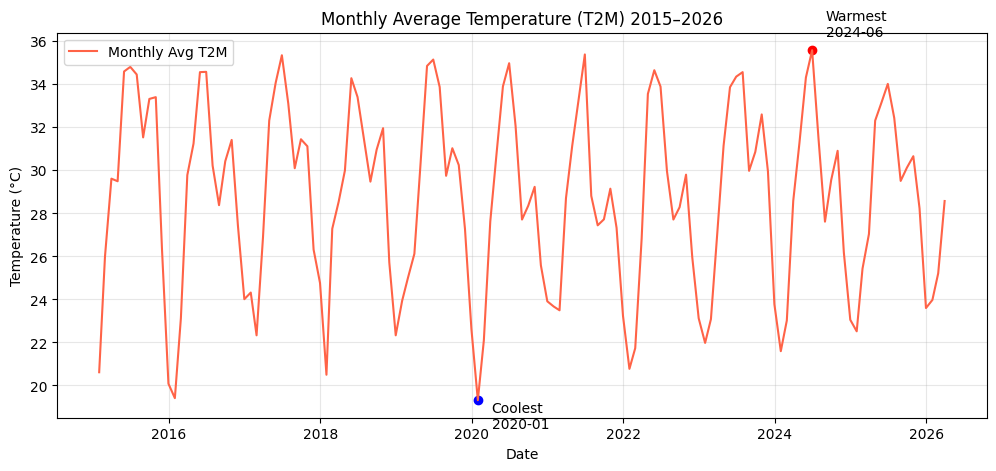

In [42]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.plot(monthly.index, monthly["T2M"], label="Monthly Avg T2M", color="tomato")

# Identify warmest and coolest months
warmest = monthly["T2M"].idxmax()
coolest = monthly["T2M"].idxmin()

plt.scatter(warmest, monthly.loc[warmest, "T2M"], color="red")
plt.scatter(coolest, monthly.loc[coolest, "T2M"], color="blue")

plt.annotate(f"Warmest\n{warmest.strftime('%Y-%m')}",
             (warmest, monthly.loc[warmest, "T2M"]),
             textcoords="offset points", xytext=(10,10))

plt.annotate(f"Coolest\n{coolest.strftime('%Y-%m')}",
             (coolest, monthly.loc[coolest, "T2M"]),
             textcoords="offset points", xytext=(10,-20))

plt.title("Monthly Average Temperature (T2M) 2015–2026")
plt.ylabel("Temperature (°C)")
plt.xlabel("Date")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

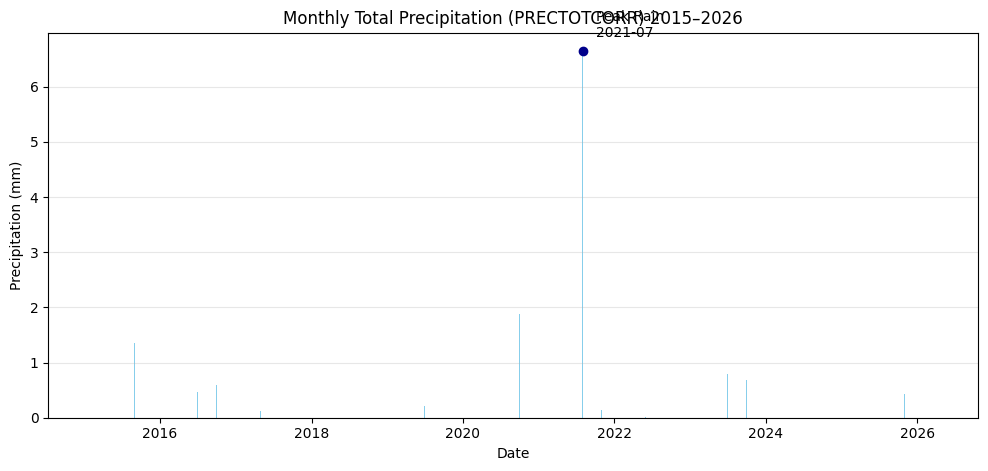

In [43]:
monthly = df[['T2M', 'PRECTOTCORR']].resample('ME').mean()
plt.figure(figsize=(12, 5))

plt.bar(monthly.index, monthly["PRECTOTCORR"], color="skyblue")

# Identify peak rainfall month
wettest = monthly["PRECTOTCORR"].idxmax()

plt.scatter(wettest, monthly.loc[wettest, "PRECTOTCORR"], color="darkblue")

plt.annotate(f"Peak Rain\n{wettest.strftime('%Y-%m')}",
             (wettest, monthly.loc[wettest, "PRECTOTCORR"]),
             textcoords="offset points", xytext=(10,10))

plt.title("Monthly Total Precipitation (PRECTOTCORR) 2015–2026")
plt.ylabel("Precipitation (mm)")
plt.xlabel("Date")
plt.grid(axis="y", alpha=0.3)

plt.show()

Heatmap of correlations across all numeric columns.

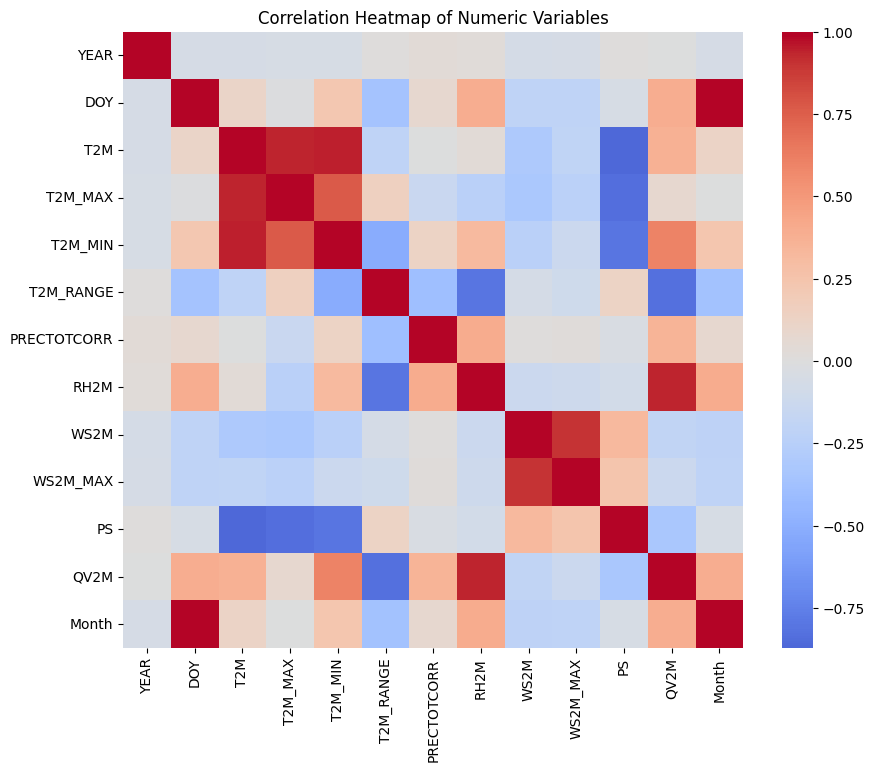

In [44]:
# Keep only numeric columns
numeric_df = df.select_dtypes(include="number")

# Compute correlation matrix
corr = numeric_df.corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)

plt.title("Correlation Heatmap of Numeric Variables")
plt.show()

T2M vs RH2M (temperature vs humidity)

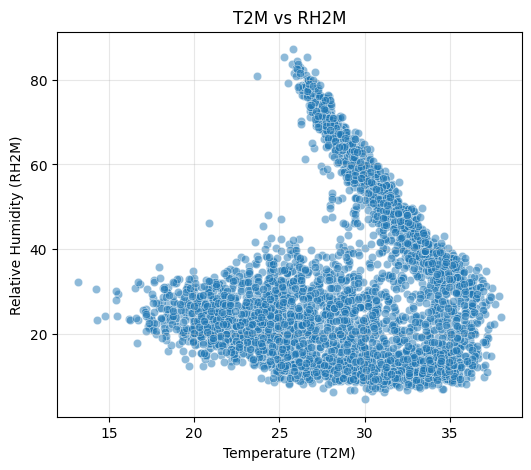

In [45]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M", y="RH2M", alpha=0.5)

plt.title("T2M vs RH2M")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")
plt.grid(True, alpha=0.3)

plt.show()

T2M_RANGE vs WS2M (temperature range vs wind speed)

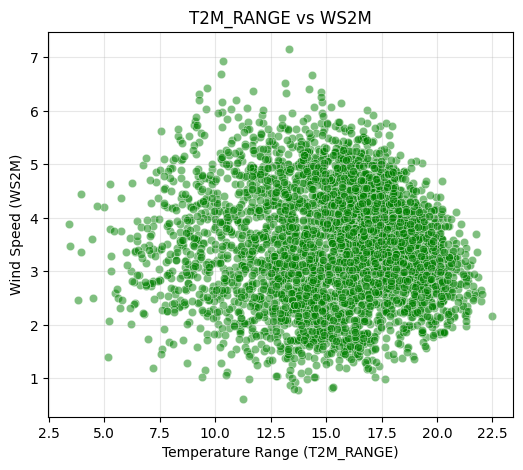

In [46]:
plt.figure(figsize=(6, 5))

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M", alpha=0.5, color="green")

plt.title("T2M_RANGE vs WS2M")
plt.xlabel("Temperature Range (T2M_RANGE)")
plt.ylabel("Wind Speed (WS2M)")
plt.grid(True, alpha=0.3)

plt.show()

Strongest Correlations Analysis
1. DOY and Month (Perfect Positive Correlation)
Correlation Strength: ~ +1.0$ (Dark Red)
Interpretation: This is a "deterministic" relationship. DOY (Day of Year, 1–365) and Month (1–12) are both measures of time within a year. As the day of the year increases, the month naturally progresses.Data Note: In predictive modeling, you would likely drop one of these, as they provide redundant information (multicollinearity).
2. T2M, T2M_MAX, and T2M_MIN (Strong Positive Correlation)
Correlation Strength: ~ +0.85$ to $+0.95$ (Deep Red)
Interpretation: These variables represent Average Temperature, Maximum Temperature, and Minimum Temperature at 2 meters.It’s no surprise that when the daily maximum is high, the daily average also tends to be high.In a climate like Sudan’s, these temperatures move in lockstep; a "hot day" usually means both the nighttime low and the daytime high are elevated.
3. T2M (Average Temp) and PS (Surface Pressure) (Strong Negative Correlation)
Correlation Strength: ~ -0.75$ to $-0.85$ (Deep Blue)
Interpretation: This represents a classic thermodynamic relationship.The Science: When the air heats up (High T2M), it expands and becomes less dense, which leads to lower atmospheric pressure at the surface (PS).Conversely, cooler air is denser and associated with higher surface pressure. This strong inverse relationship is a fundamental driver of weather patterns and wind in the region.

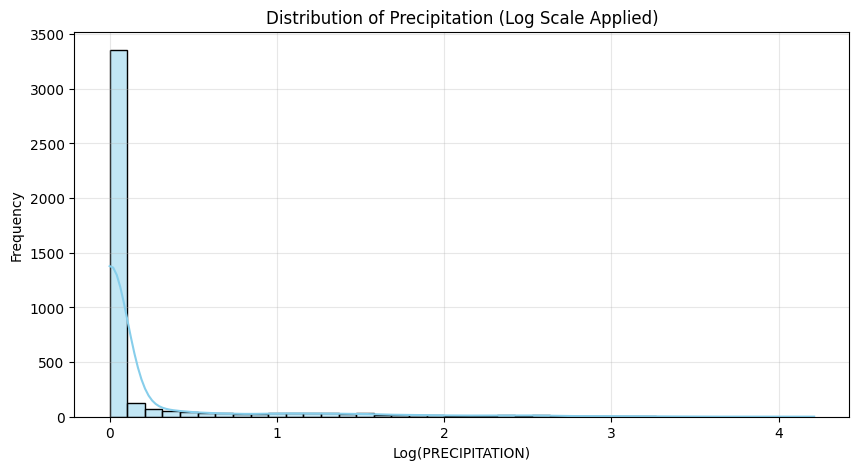

Skewness: 10.28494659239945


In [47]:
plt.figure(figsize=(10, 5))

# Check skewness
skewness = df["PRECTOTCORR"].skew()

# Apply log scale if heavily skewed
if skewness > 1:
    data = np.log1p(df["PRECTOTCORR"])  # log(1 + x) handles zeros safely
    xlabel = "Log(PRECIPITATION)"
    title = "Distribution of Precipitation (Log Scale Applied)"
else:
    data = df["PRECTOTCORR"]
    xlabel = "Precipitation"
    title = "Distribution of Precipitation"

sns.histplot(data, bins=40, kde=True, color="skyblue")

plt.title(title)
plt.xlabel(xlabel)
plt.ylabel("Frequency")
plt.grid(alpha=0.3)

plt.show()

print("Skewness:", skewness)

Bubble Chart

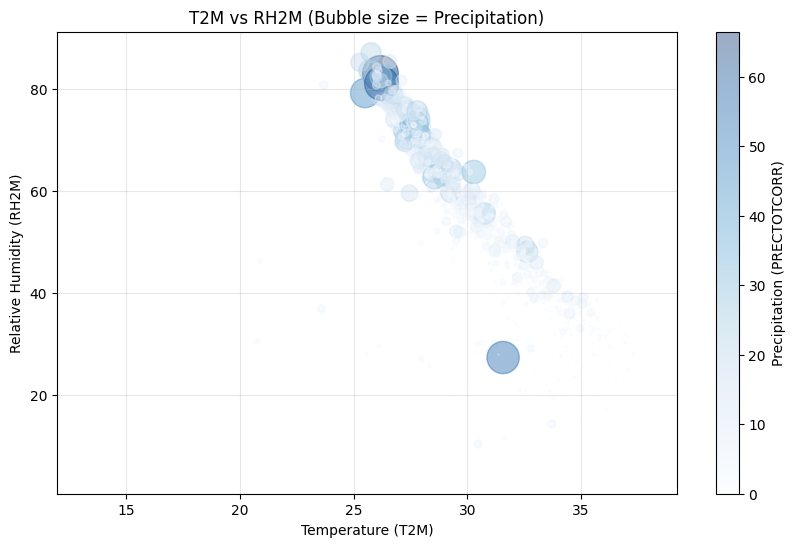

In [48]:
plt.figure(figsize=(10, 6))

# Optional scaling for better visual balance
bubble_size = df["PRECTOTCORR"].fillna(0) * 10

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=bubble_size,
    alpha=0.4,
    c=df["PRECTOTCORR"],
    cmap="Blues"
)

plt.title("T2M vs RH2M (Bubble size = Precipitation)")
plt.xlabel("Temperature (T2M)")
plt.ylabel("Relative Humidity (RH2M)")

cbar = plt.colorbar()
cbar.set_label("Precipitation (PRECTOTCORR)")

plt.grid(alpha=0.3)
plt.show()